In [1]:
import stack_tools
import importlib

/Users/calvinleung/kko_host_paper/plot_scripts/stack_tools.py:517: SyntaxWarning: invalid escape sequence '\o'
  eqn_string += f"{mxpb['x_mean']:.1f}" + '} M_\odot)'


In [2]:
from scipy.special import erf
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import Normalize
from matplotlib import cm
import numpy as np
from scipy.special import erfc, erfcx, log_ndtr
%matplotlib ipympl


In [3]:
no_marg = stack_tools._log_likelihood_ul(
    np.linspace(-10,10),
    np.atleast_1d([0]),
    np.atleast_1d([1]),
    np.atleast_1d([0]))
marg = stack_tools._log_likelihood_ul_nuisance(
    np.linspace(-10,10),
    np.atleast_1d([0]),
    np.atleast_1d([1]),
    np.atleast_1d([0]))

/Users/calvinleung/kko_host_paper/plot_scripts/stack_tools.py:157: RuntimeWarning: divide by zero encountered in log
  prior_vs_sigma = np.log(sigma_e[None,:] * ((sigma_data**2 + sigma_model**2)[:,None] + sigma_e[None,:]**2)**-1) # shape: (n_bursts, n_sigma_e)


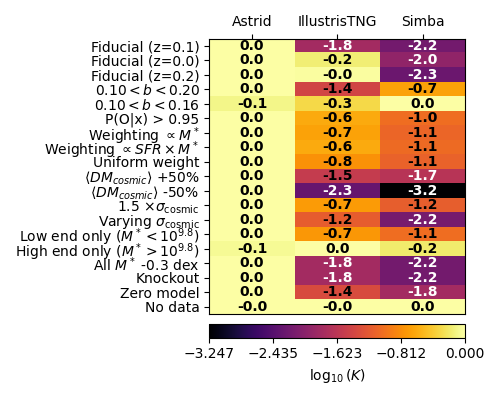

In [8]:
import pandas as pd
import dmh_tools,camels_tools
import os

models = ['Astrid','IllustrisTNG','SIMBA']
variants = [
    
    ['Fiducial (z=0.1)',('086',0.13,0.20,2,'fid0.1')],
    ['Fiducial (z=0.0)',('090',0.13,0.20,2,'fid0')],
    ['Fiducial (z=0.2)',('082',0.13,0.20,2,'fid0.2')],
    [r'$0.10 < b < 0.20$',('086',0.1,0.2,2,'lowb')],
    [r'$0.10 < b < 0.16$',('086',0.1,0.16,2,'highb')],
    [r'P(O|x) > 0.95',('086', 0.13, 0.20,2,'goldgold')],
    [r'Weighting $\propto M^*$',('086',0.13,0.2,1)],
    [r'Weighting $\propto SFR \times M^*$',('086',0.13,0.2,3)],
    ['Uniform weight' ,('086',0.13,0.20,0)],
    [r'$\langle DM_{cosmic} \rangle$ +50%',('086',0.13,0.20,2,'high_igm')],
    [r'$\langle DM_{cosmic} \rangle$ -50%',('086',0.13,0.20,2,'low_igm')],
    [r'1.5 $\times\sigma_\mathrm{cosmic}$',('086',0.13,0.20,2,'inflate_sigma_cosmic')],
    [r'Varying $\sigma_\mathrm{cosmic}$',('086',0.13,0.20,2,'varying_sigma_cosmic')],
    [r'Low end only ($M^* < 10^{9.8}$)',('086', 0.13, 0.20,2,'low')],
    [r'High end only ($M^* > 10^{9.8}$)',('086', 0.13, 0.20,2,'high')],
    [r'All $M^*$ -0.3 dex',('086', 0.13, 0.20,2,'low_mstar')],
    [r'Knockout',('086', 0.13, 0.20,2,'knockout')],
    [r'Zero model',('086', 0.13, 0.20,2,'null_model')],
    [r'No data',('086', 0.13, 0.20,2,'no_data')],
]

ROOT_PATH = os.getcwd() + '/../'
_df = pd.read_csv(os.path.join(ROOT_PATH,'data_products/remove_clusters_lowdm_edgeon.csv'))
_df.set_index('name',inplace=True)
keep = dmh_tools.not_clusters(_df) * dmh_tools.not_edge_on(_df) * dmh_tools.not_scattered(_df) * dmh_tools.not_elliptical(_df) * dmh_tools.not_low_dm(_df) * dmh_tools.not_dwarf(_df)
df = _df[keep]
plot_mstar = df['published_M*']
plot_dm = df['DM_host_restframe']
plot_dmerr = dmh_tools.sigma_tot(df)
keep = dmh_tools.not_clusters(df) * dmh_tools.not_edge_on(df) * dmh_tools.not_scattered(df) * dmh_tools.not_elliptical(df) * dmh_tools.not_low_dm(df) * dmh_tools.not_dwarf(df)

sigma_cbm_arr = np.linspace(1,100,num = 110)  #np.linspace(1,100,num = 1)
dm_cbm_arr = np.linspace(0,400,num = 80) #np.linspace(0,200, num = 1)
ll_per_variant_model_burst = np.zeros((len(variants),3,len(df),len(sigma_cbm_arr),len(dm_cbm_arr)))
ll_per_variant = np.zeros((3,len(variants)))

import importlib
importlib.reload(stack_tools)

for iivariant,(variant_name,params) in enumerate(variants):
    for iimodel,model in enumerate(models):
        keep = dmh_tools.not_low_dm(df) * dmh_tools.not_scattered(df) * dmh_tools.not_clusters(df) * dmh_tools.not_edge_on(df) * dmh_tools.not_dwarf(df) * np.array([name not in ['FRB20220319D', 'FRB20210807D'] for name in df.index])
        # analysis perturbations
        vary_igm_factor = 0
        model_mult = 1
        data_err_mult = 1
        mstar_bias_dex = 0.0    
        try:
            (snap_id, b_min, b_max, iiweight,variant) = params
        except:
            (snap_id, b_min, b_max, iiweight) = params
        if variant == 'low':
            keep = df['published_M*'] < 9.8
        elif variant == 'high':
            keep = df['published_M*'] >= 9.8
        elif variant == 'low_igm':
            vary_igm_factor = -0.5
        elif variant == 'high_igm':
            vary_igm_factor = 0.5
        elif variant == 'goldgold':
            keep = keep * np.isnan(df['primary_P_Ox']) + (df['primary_P_Ox'] > 0.95)
        elif variant == 'knockout':
            keep = keep * np.array([name not in ['FRB20220319D', 'FRB20210807D'] for name in df.index])
        elif variant == 'null_model':
            model_mult = 0
        elif variant == 'varying_sigma_cosmic':
            if model == 'SIMBA':
                data_err_mult = 0.8
            if model == 'Astrid':
                data_err_mult = 1.5
            if model == 'IllustrisTNG':
                data_err_mult = 1.0
        elif variant == 'inflate_sigma_cosmic':
            data_err_mult = 1.5
        elif variant == 'low_mstar': # if we overestimate our stellar masses
            mstar_bias_dex = -0.3
        elif variant == 'no_data':
            data_err_mult = 100
        redshift_str = f"z = {camels_tools.CAMELS_REDSHIFTS[snap_id]:.2f}"
        snap_z = camels_tools.CAMELS_REDSHIFTS[snap_id]
        stack_path = f'/Users/calvinleung/kko_host_paper/plot_scripts/../data_products/camels_stack/{model}_1P_3_0_snap{snap_id}_haloDM' + f'_bminmax={b_min:.2f}_{b_max:.2f}.h5'
        results = camels_tools.from_file(stack_path)
        results['weighted_mean'] *= model_mult
        ll_per_variant_model_burst[iivariant,iimodel,keep] = stack_tools.log_likelihood_hp_gauss(
            ms = (plot_mstar * 10**(mstar_bias_dex))[keep],
            dm = ((plot_dm + vary_igm_factor * df['dm_igm']))[keep],
            dm_err = ((plot_dmerr * data_err_mult))[keep],
            res=results,
            sigma_cbm_arr = sigma_cbm_arr,
            dm_cbm_arr = dm_cbm_arr,
            weight_index = iiweight)
    prior = 1/sigma_cbm_arr[:,None] * (dm_cbm_arr[None,:] > (3* sigma_cbm_arr[:,None]))
    ll_per_variant[:,iivariant] = stack_tools.marginalize_ll_hp(
                                        ll_per_variant_model_burst[iivariant],
                                        prior,
                                        dm_cbm_arr,
                                        sigma_cbm_arr,
                                    )
fig = plt.figure(figsize = (5,4))
#plt.title(r'Bayes')
stack_tools.plot_fig2(fig,plt.gca(),ll_per_variant * np.log10(np.e), cmap = 'inferno',xnames = ['Astrid','IllustrisTNG','Simba'], 
    ynames = np.array([v[0] for v in variants]), cbar_label = r'$\log_{10}(K)$',
    #out_file = os.path.join(ROOT_PATH,'figures/model_selection_ul.pdf')
                     )
plt.tight_layout()

In [9]:
ll_per_variant_model_burst.shape

(19, 3, 20, 110, 80)

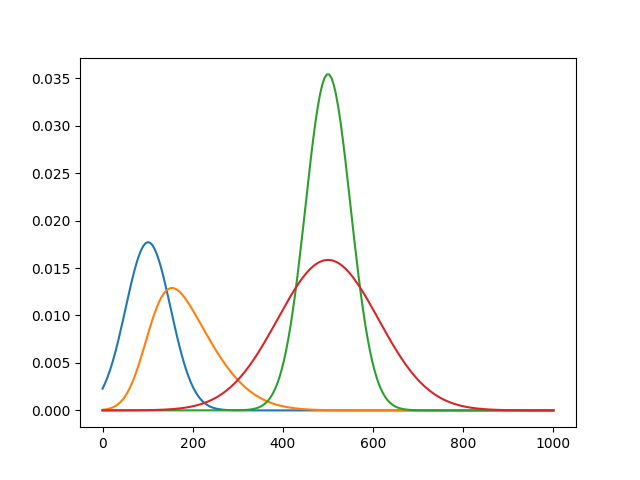

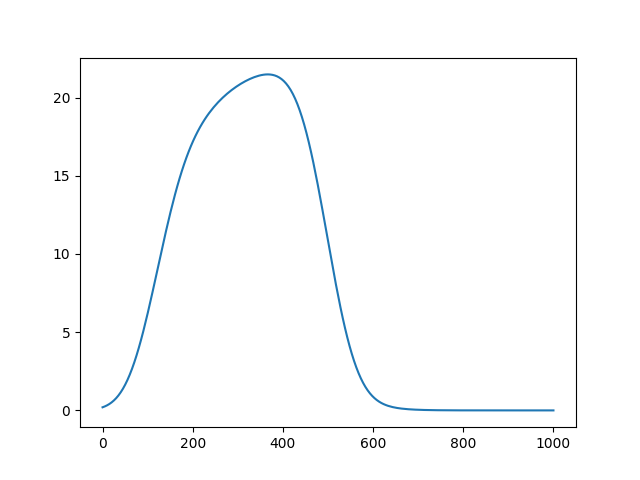

In [10]:
dm_test = np.linspace(0,1000,num = 200)
test= np.array(list(map(lambda x: stack_tools.log_likelihood_mgaussian(
            dm_host_restframe = x,
            sigma_i = 50,
            dm_model = 100,
            sigma_cbm_arr = sigma_cbm_arr,
            dm_cbm_arr = dm_cbm_arr),
    dm_test,
)))

ans = np.zeros(200)
for ii,_test in enumerate(test):
    ans[ii] = stack_tools.marginalize_ll_hp(_test,prior = prior, dm_cbm_arr = dm_cbm_arr, sigma_cbm_arr = sigma_cbm_arr).squeeze()

plt.figure()
plt.plot(dm_test,np.exp(test[:,0,0]))
plt.plot(dm_test,np.exp(test[:,-1,0]))
plt.plot(dm_test,np.exp(test[:,0,-1]))
plt.plot(dm_test,np.exp(test[:,-1,-1]))

plt.figure()
plt.plot(dm_test,np.exp(ans))

In [17]:
ll_per_variant_model_burst_test = np.zeros((200,len(plot_dm),len(sigma_cbm_arr),len(dm_cbm_arr)))
for ii,dm_model in enumerate(np.linspace(0,200,num = 200)):
    results['weighted_mean'] *= 0
    results['weighted_mean'] += dm_model
    ll_per_variant_model_burst_test[ii] = stack_tools.log_likelihood_hp_gauss(
        ms = (plot_mstar * 10**(mstar_bias_dex)),
        dm = ((plot_dm + vary_igm_factor * df['dm_igm'])),
        dm_err = ((plot_dmerr * data_err_mult)),
        res=results,
        sigma_cbm_arr = sigma_cbm_arr,
        dm_cbm_arr = dm_cbm_arr,
        weight_index = 2
    )

In [18]:
def find_argmax(x,y,xy):
    shape = xy.shape
    iy,ix = np.unravel_index(np.argmax(xy.flat),shape)
    return x[ix],y[iy]

/var/folders/2v/13b457dx6qn34sd445522vnc0000gp/T/ipykernel_33111/1191332989.py:4: RuntimeWarning: divide by zero encountered in log
  ans = np.log(prior) + np.sum(ll_per_variant_model_burst,axis = 2)[0,iimodel]


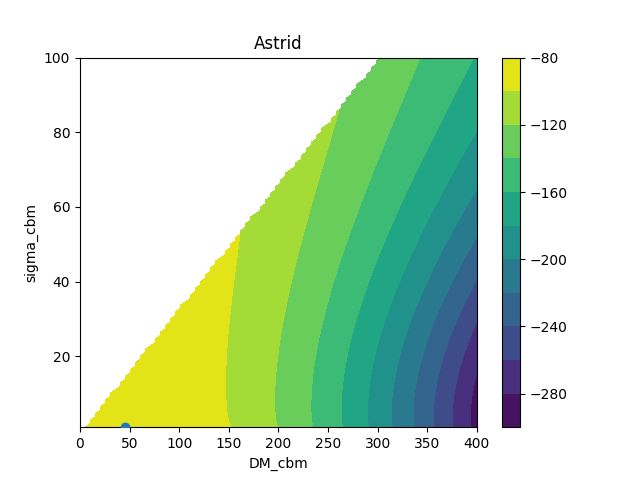

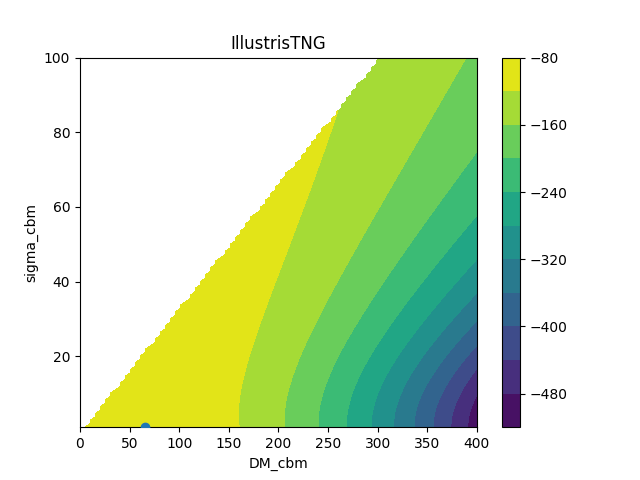

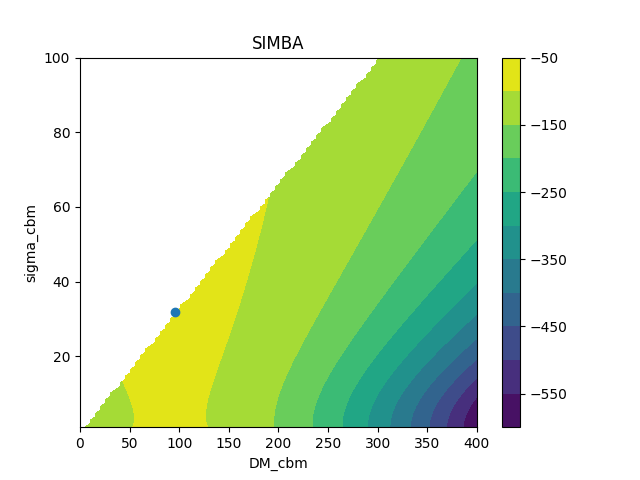

In [19]:

for iimodel,model in enumerate(models):
    plt.figure()
    plt.title(model)
    ans = np.log(prior) + np.sum(ll_per_variant_model_burst,axis = 2)[0,iimodel]
    x,y = find_argmax(dm_cbm_arr,sigma_cbm_arr,ans)
    plt.scatter(x,y,zorder = 10)
    plt.contourf(dm_cbm_arr,sigma_cbm_arr,ans,levels = 10)
    plt.xlabel('DM_cbm')
    plt.ylabel('sigma_cbm')
    plt.colorbar()


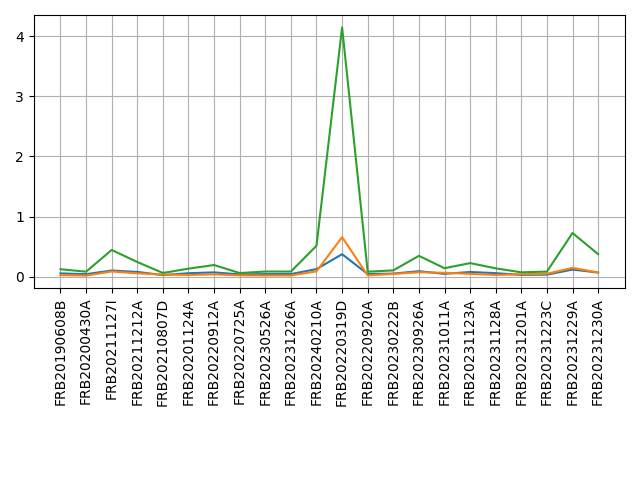

In [117]:
plt.figure()
plt.plot(df.index,(np.max(np.abs(ll_per_variant_model_burst[3] - ll_per_variant_model_burst[0]),axis = (-2,-1))).T)
plt.xticks(rotation=90)
plt.grid(True)
plt.tight_layout()
plt.subplots_adjust(bottom=0.4)

In [35]:
np.sum(np.exp(ll_per_variant_model_burst[3]) - ll_per_variant_model_burst[0]

SyntaxError: incomplete input (1883278681.py, line 1)

# Check the integral

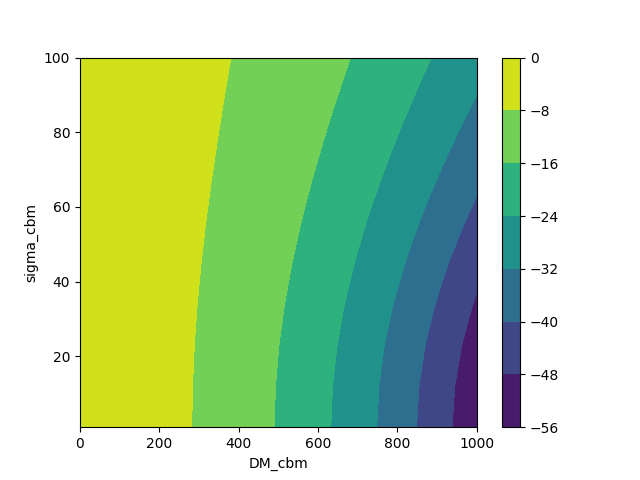

In [146]:
sigma_cbm_arr = np.linspace(1,100,num = 10)
dm_cbm_arr = np.linspace(0,1000)
ans = stack_tools.log_likelihood_mgaussian(dm_host_restframe = 100, sigma_i = 100, 
                                                  dm_model = 100,sigma_cbm_arr = sigma_cbm_arr, 
                                                  dm_cbm_arr=dm_cbm_arr).squeeze()
plt.figure()
plt.contourf(dm_cbm_arr,sigma_cbm_arr,ans)
plt.xlabel('DM_cbm')
plt.ylabel('sigma_cbm')
plt.colorbar()


In [178]:

numerical_integral(a = 100,b = 10,w = (1/80)**2, S = (1/100)**2, mu = np.log(10))

8111.204652077846

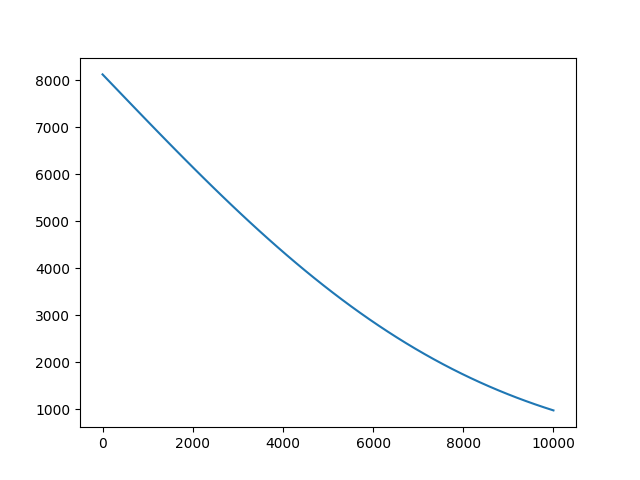

In [181]:
plt.figure()
plt.plot(np.linspace(0,10000),
         np.array([numerical_integral(a = 100,b = x,w = (1/80)**2, S = (1/100)**2, mu = np.log(10)) for x in np.linspace(0,10000)]))

In [40]:
import numpy as np
from scipy.integrate import quad
from scipy.stats import lognorm
import warnings

def lognormal_pdf(x, mu, sigma):
    """
    Log-normal probability density function
    
    Parameters:
    -----------
    x : array_like
        Values at which to evaluate the PDF (must be positive)
    mu : float
        Location parameter (mean of underlying normal)
    sigma : float
        Scale parameter (std of underlying normal)
    
    Returns:
    --------
    array_like : PDF values
    """
    if np.any(x <= 0):
        return np.where(x <= 0, 0.0, 
                       (1/(x * sigma * np.sqrt(2*np.pi))) * 
                       np.exp(-(np.log(x) - mu)**2 / (2*sigma**2)))
    return (1/(x * sigma * np.sqrt(2*np.pi))) * np.exp(-(np.log(x) - mu)**2 / (2*sigma**2))

def likelihood_single_point(y, mu_x, sigma_x, mu_eps, sigma_eps, 
                           integration_limit=None, epsabs=1e-10, epsrel=1e-8):
    """
    Compute likelihood for a single observed data point y = x + epsilon
    where x ~ LogNormal(mu_x, sigma_x) and epsilon ~ LogNormal(mu_eps, sigma_eps)
    
    Parameters:
    -----------
    y : float
        Observed data point (must be positive)
    mu_x, sigma_x : float
        Parameters of log-normal distribution for x
    mu_eps, sigma_eps : float  
        Parameters of log-normal distribution for epsilon
    integration_limit : float, optional
        Upper limit for integration. If None, uses min(y, auto_limit)
    epsabs, epsrel : float
        Absolute and relative error tolerances for integration
    
    Returns:
    --------
    float : Likelihood value L(parameters | y)
    """
    if y <= 0:
        return 0.0
    
    def integrand(x):
        """Integrand: f_X(x) * f_E(y-x)"""
        if x <= 0 or x >= y:
            return 0.0
        
        eps_val = y - x
        if eps_val <= 0:
            return 0.0
            
        # f_X(x) * f_E(y-x)
        fx = lognormal_pdf(x, mu_x, sigma_x)
        fe = lognormal_pdf(eps_val, mu_eps, sigma_eps)
        
        return fx * fe
    
    # Determine integration limits
    # We integrate from 0 to y (since both x and epsilon must be positive)
    # But we can be smarter about the upper limit
    if integration_limit is None:
        # Use a reasonable upper bound based on the distributions
        # Most mass of log-normal is within exp(mu + 3*sigma)
        x_upper = np.exp(mu_x + 3*sigma_x)
        integration_limit = min(y * 0.999, x_upper)  # Leave small margin from y
    
    try:
        result, error = quad(integrand, 0, integration_limit, 
                           epsabs=epsabs, epsrel=epsrel, limit=100)
        
        # Check if integration error is reasonable
        if error > result * 0.01:  # More than 1% relative error
            warnings.warn(f"Integration error ({error:.2e}) is large relative to result ({result:.2e})")
            
        return max(result, 1e-300)  # Avoid exact zeros for log-likelihood
        
    except Exception as e:
        warnings.warn(f"Integration failed for y={y}: {str(e)}")
        return 1e-300

def likelihood_vectorized(y_data, mu_x, sigma_x, mu_eps, sigma_eps, 
                         integration_limit=None, epsabs=1e-10, epsrel=1e-8):
    """
    Compute likelihood for multiple data points
    
    Parameters:
    -----------
    y_data : array_like
        Observed data points
    mu_x, sigma_x : float
        Parameters of log-normal distribution for x  
    mu_eps, sigma_eps : float
        Parameters of log-normal distribution for epsilon
    integration_limit : float, optional
        Upper limit for integration for all points
    epsabs, epsrel : float
        Integration tolerances
    
    Returns:
    --------
    ndarray : Likelihood values for each data point
    """
    y_data = np.asarray(y_data)
    
    if y_data.ndim == 0:
        return likelihood_single_point(y_data.item(), mu_x, sigma_x, mu_eps, sigma_eps,
                                     integration_limit, epsabs, epsrel)
    
    results = np.zeros_like(y_data, dtype=float)
    
    for i, y in enumerate(y_data):
        results[i] = likelihood_single_point(y, mu_x, sigma_x, mu_eps, sigma_eps,
                                           integration_limit, epsabs, epsrel)
    
    return results

def log_likelihood(y_data, mu_x, sigma_x, mu_eps, sigma_eps, **kwargs):
    """
    Compute log-likelihood for observed data
    
    Parameters:
    -----------
    y_data : array_like
        Observed data points
    mu_x, sigma_x : float
        Parameters of log-normal distribution for x
    mu_eps, sigma_eps : float
        Parameters of log-normal distribution for epsilon
    **kwargs : Additional arguments passed to likelihood computation
    
    Returns:
    --------
    float : Log-likelihood value
    """
    likelihoods = likelihood_vectorized(y_data, mu_x, sigma_x, mu_eps, sigma_eps, **kwargs)
    
    # Handle zeros/very small values
    likelihoods = np.maximum(likelihoods, 1e-300)
    
    return np.sum(np.log(likelihoods))

def monte_carlo_likelihood(y, mu_x, sigma_x, mu_eps, sigma_eps, n_samples=10000):
    """
    Alternative Monte Carlo approach for computing likelihood
    L(y) ≈ (1/N) * sum(f_E(y - x_i)) where x_i ~ LogNormal(mu_x, sigma_x)
    
    This can be faster but less accurate than numerical integration.
    """
    if y <= 0:
        return 0.0
    
    # Sample from x distribution
    x_samples = np.random.lognormal(mu_x, sigma_x, n_samples)
    
    # Compute epsilon values
    eps_samples = y - x_samples
    
    # Only keep valid epsilon values (positive)
    valid_mask = eps_samples > 0
    if np.sum(valid_mask) == 0:
        return 1e-300
    
    eps_valid = eps_samples[valid_mask]
    
    # Compute f_E(epsilon) for valid samples
    fe_values = lognormal_pdf(eps_valid, mu_eps, sigma_eps)
    
    # Monte Carlo approximation
    return np.mean(fe_values) * np.sum(valid_mask) / n_samples

def test_implementation():
    """Test the likelihood implementation with known cases"""
    print("Testing Log-Normal Sum Likelihood Implementation")
    print("=" * 55)
    
    # Test parameters
    mu_x, sigma_x = 1.0, 0.5  # x parameters
    mu_eps, sigma_eps = 0.5, 0.3  # epsilon parameters
    
    # Generate some test data
    np.random.seed(42)
    n_samples = 5
    x_true = np.random.lognormal(mu_x, sigma_x, n_samples)
    eps_true = np.random.lognormal(mu_eps, sigma_eps, n_samples)  
    y_data = x_true + eps_true
    
    print(f"Test data: {y_data}")
    print(f"True x values: {x_true}")
    print(f"True epsilon values: {eps_true}")
    
    # Test 1: Single point likelihood
    print("\nTest 1: Single point likelihood")
    y_test = y_data[0]
    likelihood_val = likelihood_single_point(y_test, mu_x, sigma_x, mu_eps, sigma_eps)
    mc_likelihood = monte_carlo_likelihood(y_test, mu_x, sigma_x, mu_eps, sigma_eps)
    
    print(f"y = {y_test:.4f}")
    print(f"Numerical integration: {likelihood_val:.8f}")
    print(f"Monte Carlo (10k):     {mc_likelihood:.8f}")
    print(f"Ratio MC/Numerical:    {mc_likelihood/likelihood_val:.4f}")
    
    # Test 2: Vectorized likelihood
    print("\nTest 2: Vectorized likelihood")
    likelihood_vec = likelihood_vectorized(y_data, mu_x, sigma_x, mu_eps, sigma_eps)
    print("Likelihood values:")
    for i, (y, l) in enumerate(zip(y_data, likelihood_vec)):
        print(f"  y[{i}] = {y:.4f}, L = {l:.8f}")
    
    # Test 3: Log-likelihood
    print("\nTest 3: Log-likelihood")
    ll = log_likelihood(y_data, mu_x, sigma_x, mu_eps, sigma_eps)
    print(f"Log-likelihood: {ll:.6f}")
    
    # Test 4: Parameter sensitivity
    print("\nTest 4: Parameter sensitivity")
    params_to_test = [
        (mu_x, sigma_x, mu_eps, sigma_eps),  # True parameters
        (mu_x + 0.2, sigma_x, mu_eps, sigma_eps),  # Shifted mu_x
        (mu_x, sigma_x + 0.1, mu_eps, sigma_eps),  # Increased sigma_x
        (mu_x, sigma_x, mu_eps + 0.2, sigma_eps),  # Shifted mu_eps
        (mu_x, sigma_x, mu_eps, sigma_eps + 0.1),  # Increased sigma_eps
    ]
    
    param_names = ['True', '+0.2 mu_x', '+0.1 sigma_x', '+0.2 mu_eps', '+0.1 sigma_eps']
    
    for name, (mx, sx, me, se) in zip(param_names, params_to_test):
        ll_test = log_likelihood(y_data, mx, sx, me, se)
        print(f"{name:15s}: LL = {ll_test:8.4f}")
    
    # Test 5: Edge cases
    print("\nTest 5: Edge cases")
    
    # Very small y
    y_small = 0.01
    l_small = likelihood_single_point(y_small, mu_x, sigma_x, mu_eps, sigma_eps)
    print(f"Very small y ({y_small}): L = {l_small:.2e}")
    
    # Large y
    y_large = 100.0
    l_large = likelihood_single_point(y_large, mu_x, sigma_x, mu_eps, sigma_eps)
    print(f"Large y ({y_large}):        L = {l_large:.2e}")
    
    # Zero or negative y (should return 0)
    l_zero = likelihood_single_point(0.0, mu_x, sigma_x, mu_eps, sigma_eps)
    l_neg = likelihood_single_point(-1.0, mu_x, sigma_x, mu_eps, sigma_eps)
    print(f"y = 0:              L = {l_zero}")
    print(f"y = -1:             L = {l_neg}")

if __name__ == "__main__":
    test_implementation()

Testing Log-Normal Sum Likelihood Implementation
Test data: [5.02150025 5.18460169 5.83339859 7.2533721  4.35811312]
True x values: [3.4846133  2.5367097  3.75783979 5.82124949 2.41795783]
True epsilon values: [1.53688696 2.64789198 2.0755588  1.43212261 1.94015528]

Test 1: Single point likelihood
y = 5.0215
Numerical integration: 0.22179529
Monte Carlo (10k):     0.22215710
Ratio MC/Numerical:    1.0016

Test 2: Vectorized likelihood
Likelihood values:
  y[0] = 5.0215, L = 0.22179529
  y[1] = 5.1846, L = 0.20513283
  y[2] = 5.8334, L = 0.14311729
  y[3] = 7.2534, L = 0.05655258
  y[4] = 4.3581, L = 0.28095929

Test 3: Log-likelihood
Log-likelihood: -9.176319

Test 4: Parameter sensitivity
True           : LL =  -9.1763
+0.2 mu_x      : LL =  -8.5011
+0.1 sigma_x   : LL =  -9.6059
+0.2 mu_eps    : LL =  -8.3880
+0.1 sigma_eps : LL =  -9.1220

Test 5: Edge cases
Very small y (0.01): L = 3.28e-111
Large y (100.0):        L = 1.97e-42
y = 0:              L = 0.0
y = -1:             L = 0

/var/folders/2v/13b457dx6qn34sd445522vnc0000gp/T/ipykernel_33111/49689354.py:85: UserWarning: Integration error (1.04e-111) is large relative to result (3.28e-111)
  warnings.warn(f"Integration error ({error:.2e}) is large relative to result ({result:.2e})")
/var/folders/2v/13b457dx6qn34sd445522vnc0000gp/T/ipykernel_33111/49689354.py:85: UserWarning: Integration error (2.55e-44) is large relative to result (1.97e-42)
  warnings.warn(f"Integration error ({error:.2e}) is large relative to result ({result:.2e})")


In [41]:
%pdb on

Automatic pdb calling has been turned ON


In [54]:
mu_cgm = 100
sigma_cgm = 50
mu_cbm = 50
sigma_cbm = 40 

mu_x = np.log(mu_cgm**2 / (mu_cgm**2 + sigma_cgm**2)**0.5)
sigma_x = np.log(1 + sigma_cgm**2 / mu_cgm**2)
mu_eps = np.log(mu_cbm**2 / (mu_cbm**2 + sigma_cbm**2)**0.5)
sigma_eps = np.log(1 + sigma_cbm**2 / mu_cbm**2)

print(mu_x,sigma_x,mu_eps,sigma_eps)

4.4935984103309865 0.22314355131420976 3.6646748845100925 0.4946962418361071


/var/folders/2v/13b457dx6qn34sd445522vnc0000gp/T/ipykernel_33111/49689354.py:85: UserWarning: Integration error (2.30e-122) is large relative to result (1.67e-122)
  warnings.warn(f"Integration error ({error:.2e}) is large relative to result ({result:.2e})")
/var/folders/2v/13b457dx6qn34sd445522vnc0000gp/T/ipykernel_33111/49689354.py:85: UserWarning: Integration error (3.53e-90) is large relative to result (2.60e-90)
  warnings.warn(f"Integration error ({error:.2e}) is large relative to result ({result:.2e})")
/var/folders/2v/13b457dx6qn34sd445522vnc0000gp/T/ipykernel_33111/49689354.py:85: UserWarning: Integration error (1.10e-73) is large relative to result (8.18e-74)
  warnings.warn(f"Integration error ({error:.2e}) is large relative to result ({result:.2e})")
/var/folders/2v/13b457dx6qn34sd445522vnc0000gp/T/ipykernel_33111/49689354.py:85: UserWarning: Integration error (3.19e-63) is large relative to result (3.74e-63)
  warnings.warn(f"Integration error ({error:.2e}) is large relati

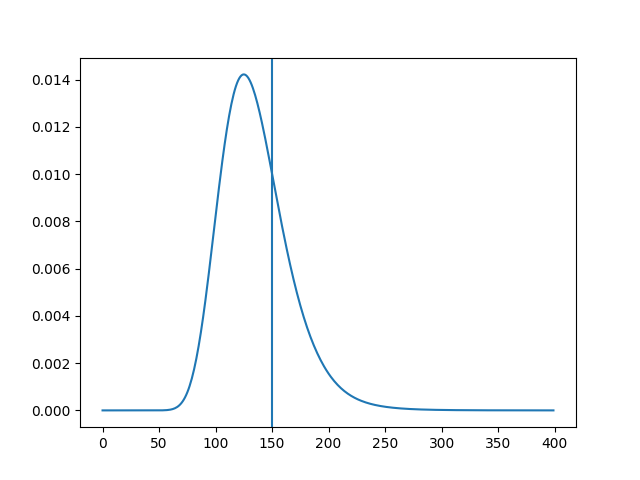

In [59]:
plt.figure()
plt.plot(
    np.arange(400),
    ([likelihood_vectorized(x, mu_x = mu_x, sigma_x= sigma_x, mu_eps = mu_eps, sigma_eps = sigma_eps) for x in np.arange(400)]),
)
plt.axvline(mu_cgm + mu_cbm)


In [ ]:
k